# Customer Cohort Retention Analysis

## 1. Project Objective

The objective of this project is to analyze customer retention
over time using cohort analysis.

Customers are grouped according to their first purchase month,
and their subsequent purchasing behavior is tracked across
different months.

### Key Objectives

- Understand customer retention over time
- Identify customer cohorts based on first purchase month
- Calculate monthly retention percentages
- Create a cohort retention table
- Visualize retention using a heatmap
- Generate actionable business insights

## 2. Import Required Libraries

The following Python libraries are used for data analysis,
data manipulation, numerical calculations, and visualization.

### Libraries Used

- **Pandas** – Data loading, cleaning, grouping, and analysis
- **NumPy** – Numerical operations
- **Matplotlib** – Data visualization
- **Seaborn** – Statistical visualization and heatmap creation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load the Dataset

The Online Retail II dataset is loaded into a Pandas DataFrame.

The dataset contains retail transaction information such as
invoice details, products, quantities, prices, customer IDs,
transaction dates, and countries.

In [5]:
df = pd.read_excel(
    "../data/online_retail_II.xlsx",
    sheet_name=0
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 4. Initial Data Exploration

The dataset is explored to understand its structure, dimensions,
column names, data types, and sample records.

The following checks are performed:

- Dataset shape
- Column names
- Data types
- First few records
- Missing values

In [6]:
df.shape

(525461, 8)

In [7]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [9]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 5. Check Missing Values

Missing values are identified using the `isnull()` function.

Customer ID is particularly important for cohort analysis because
customers need to be tracked across different transactions and
months.

Records without Customer ID cannot be reliably assigned to a
customer cohort.

In [10]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

## 6. Remove Missing Customer IDs

Rows with missing Customer IDs are removed because Customer ID is
required to track individual customers over time.

Without a Customer ID, it is not possible to determine whether
transactions belong to the same customer.

In [12]:
df = df.dropna(subset=['Customer ID'])

In [13]:
df['Customer ID'] = df['Customer ID'].astype(int)

## 7. Convert InvoiceDate

The InvoiceDate column contains the date and time of each transaction.

It is converted into Pandas datetime format so that transaction
dates can be used for monthly cohort analysis.

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
df['InvoiceDate'].head()

0   2009-12-01 07:45:00
1   2009-12-01 07:45:00
2   2009-12-01 07:45:00
3   2009-12-01 07:45:00
4   2009-12-01 07:45:00
Name: InvoiceDate, dtype: datetime64[ns]

## 8. Identify Cancelled Transactions

In the Online Retail II dataset, cancelled invoices are identified
by invoice numbers beginning with the letter `C`.

Cancelled transactions are identified before removal so that the
number of cancelled records can be documented.

These transactions are excluded from the cohort retention analysis
because they do not represent completed purchases.

In [16]:
df['Invoice'].astype(str).str.startswith('C').sum()

9839

## 9. Remove Cancelled Transactions

Cancelled invoices are identified by invoice numbers beginning with the letter 'C'.

Since cancelled transactions do not represent completed purchases, they are removed before performing cohort retention analysis.

In [18]:
df = df[
    ~df['Invoice'].astype(str).str.startswith('C')
]

In [19]:
df['Invoice'].astype(str).str.startswith('C').sum()

0

## 10. Remove Invalid Transactions

Transactions with zero or negative quantities or prices are excluded because they do not represent valid completed purchases.

In [20]:
df = df[df['Quantity'] > 0]

In [21]:
df = df[df['Price'] > 0]

In [22]:
df[['Quantity', 'Price']].describe()

,Quantity,Price
count,407664.000000,407664.000000
mean,13.585585,3.294438
std,96.840747,34.757965
min,1.000000,0.001000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,19152.000000,10953.500000


## 11. Create Invoice Month

The InvoiceDate column contains the date and time of each transaction.

For cohort analysis, transactions are analyzed month by month.
Therefore, InvoiceDate is converted into a monthly period called InvoiceMonth.

In [23]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

In [24]:
df[['InvoiceDate', 'InvoiceMonth']].head()

,InvoiceDate,InvoiceMonth
0,2009-12-01 07:45:00,2009-12
1,2009-12-01 07:45:00,2009-12
2,2009-12-01 07:45:00,2009-12
3,2009-12-01 07:45:00,2009-12
4,2009-12-01 07:45:00,2009-12


## 12. Identify Customer Cohort Month

A cohort represents customers who made their first purchase during the same month.

For each customer, the earliest InvoiceMonth is identified as their CohortMonth.
This CohortMonth remains the same for that customer across all transactions.

In [25]:
df['CohortMonth'] = (
    df.groupby('Customer ID')['InvoiceMonth']
      .transform('min')
)

In [26]:
df[['Customer ID', 'InvoiceMonth', 'CohortMonth']].head(10)

,Customer ID,InvoiceMonth,CohortMonth
0,13085,2009-12,2009-12
1,13085,2009-12,2009-12
2,13085,2009-12,2009-12
3,13085,2009-12,2009-12
4,13085,2009-12,2009-12
5,13085,2009-12,2009-12
6,13085,2009-12,2009-12
7,13085,2009-12,2009-12
8,13085,2009-12,2009-12
9,13085,2009-12,2009-12


## 13. Extract Cohort and Invoice Year/Month

To calculate the number of months between a customer's first purchase
and subsequent purchases, we extract the year and month from
CohortMonth and InvoiceMonth.

In [27]:
df['CohortYear'] = df['CohortMonth'].dt.year
df['CohortMonthNum'] = df['CohortMonth'].dt.month

df['InvoiceYear'] = df['InvoiceMonth'].dt.year
df['InvoiceMonthNum'] = df['InvoiceMonth'].dt.month

In [28]:
df[
    ['CohortMonth', 'CohortYear', 'CohortMonthNum',
     'InvoiceMonth', 'InvoiceYear', 'InvoiceMonthNum']
].head()

,CohortMonth,CohortYear,CohortMonthNum,InvoiceMonth,InvoiceYear,InvoiceMonthNum
0,2009-12,2009,12,2009-12,2009,12
1,2009-12,2009,12,2009-12,2009,12
2,2009-12,2009,12,2009-12,2009,12
3,2009-12,2009,12,2009-12,2009,12
4,2009-12,2009,12,2009-12,2009,12


## 14. Calculate Cohort Index

Cohort Index represents the number of months since the customer's
first purchase.

The first purchase month is assigned index 1, the following month
is index 2, and so on.

In [29]:
df['CohortIndex'] = (
    (df['InvoiceYear'] - df['CohortYear']) * 12
    + (df['InvoiceMonthNum'] - df['CohortMonthNum'])
    + 1
)

In [30]:
df[
    ['Customer ID', 'CohortMonth', 'InvoiceMonth', 'CohortIndex']
].head(10)

,Customer ID,CohortMonth,InvoiceMonth,CohortIndex
0,13085,2009-12,2009-12,1
1,13085,2009-12,2009-12,1
2,13085,2009-12,2009-12,1
3,13085,2009-12,2009-12,1
4,13085,2009-12,2009-12,1
5,13085,2009-12,2009-12,1
6,13085,2009-12,2009-12,1
7,13085,2009-12,2009-12,1
8,13085,2009-12,2009-12,1
9,13085,2009-12,2009-12,1


## 15. Count Unique Customers by Cohort

Customers may make multiple transactions during the same month.
Therefore, we count unique Customer IDs rather than transactions.

This gives us the number of active customers for each cohort period.

In [31]:
cohort_data = (
    df.groupby(
        ['CohortMonth', 'CohortIndex']
    )['Customer ID']
    .nunique()
    .reset_index()
)

In [32]:
cohort_data.head(10)

,CohortMonth,CohortIndex,Customer ID
0,2009-12,1,955
1,2009-12,2,337
2,2009-12,3,319
3,2009-12,4,406
4,2009-12,5,363
5,2009-12,6,343
6,2009-12,7,360
7,2009-12,8,327
8,2009-12,9,321
9,2009-12,10,346


## 16. Create Cohort Customer Table

A pivot table is created to show the number of unique customers
for each cohort across different months since their first purchase.

In [33]:
cohort_table = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer ID'
)

In [34]:
cohort_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,403.0,473.0,237.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,116.0,38.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,27.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,20.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,20.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 17. Calculate Customer Retention Percentage

Retention percentage shows what percentage of the original customers
in each cohort remained active in subsequent months.

The first month of each cohort represents 100% retention.

Retention Rate =
Customers Active in a Cohort Period
------------------------------------ × 100
Original Cohort Customers

In [36]:
retention_table = cohort_table.divide(
    cohort_table.iloc[:, 0],
    axis=0
) * 100

In [37]:
retention_table = retention_table.round(2)

In [38]:
retention_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,42.20,49.53,24.82
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,30.29,9.92,NaN
2010-02,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,7.22,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,6.80,NaN,NaN,NaN,NaN
2010-05,100.0,15.75,16.93,17.32,17.72,25.59,21.26,7.87,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.41,18.89,20.37,22.96,28.52,6.67,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.59,18.28,29.57,29.03,10.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.37,29.63,32.10,11.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 18. Validate Retention Table

The first cohort period should contain 100% retention because it
represents the original number of customers in each cohort.

This validation confirms that the retention calculation has been
performed correctly.

In [39]:
retention_table.iloc[:, 0]

CohortMonth
2009-12    100.0
2010-01    100.0
2010-02    100.0
2010-03    100.0
2010-04    100.0
2010-05    100.0
2010-06    100.0
2010-07    100.0
2010-08    100.0
2010-09    100.0
2010-10    100.0
2010-11    100.0
2010-12    100.0
Freq: M, Name: 1, dtype: float64

In [40]:
retention_table.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,42.20,49.53,24.82
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,30.29,9.92,NaN
2010-02,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,7.22,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,6.80,NaN,NaN,NaN,NaN


## 19. Create Cohort Retention Heatmap

A heatmap is used to visualize customer retention across different
cohorts and months.

Each cell represents the percentage of customers retained from the
original cohort.

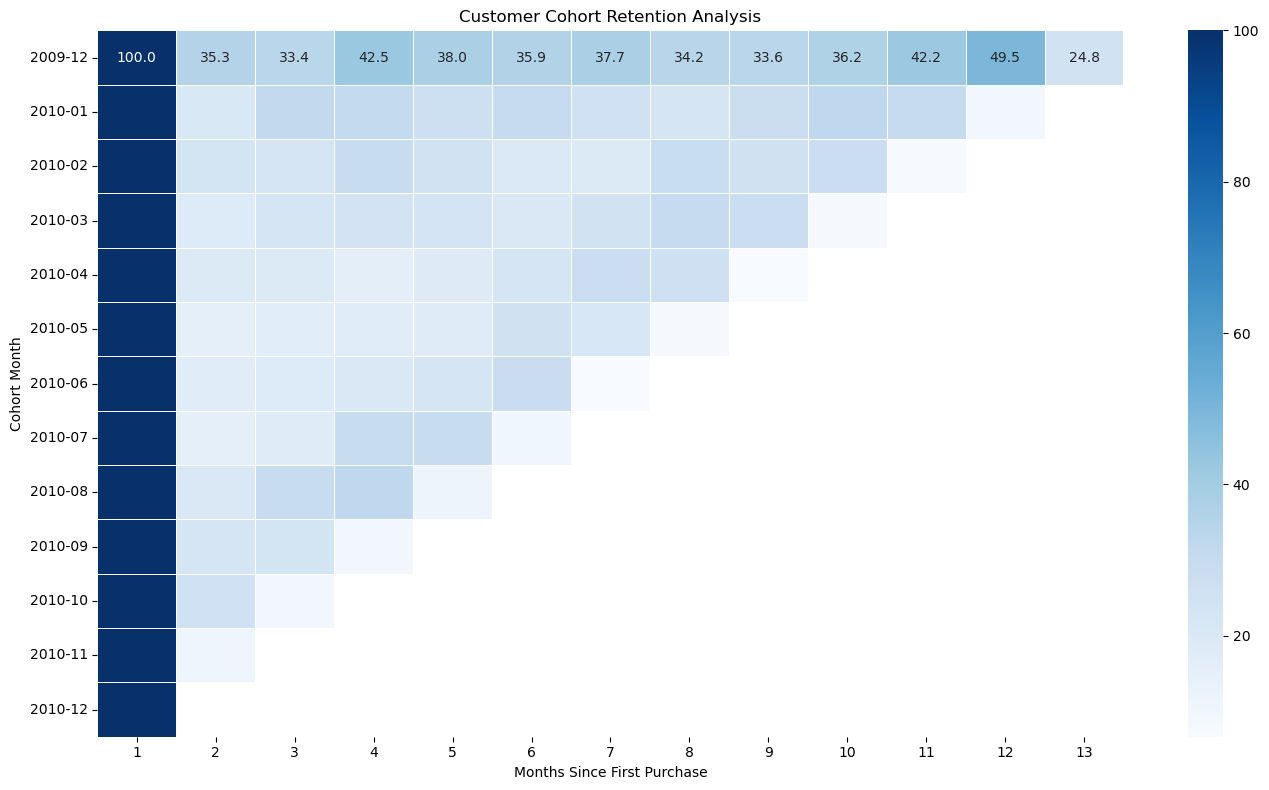

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_table,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Customer Cohort Retention Analysis')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')

plt.tight_layout()
plt.show()

## 20. Save Cohort Retention Heatmap

The retention heatmap is saved as a PNG image so that it can be
included in the project documentation and GitHub repository.

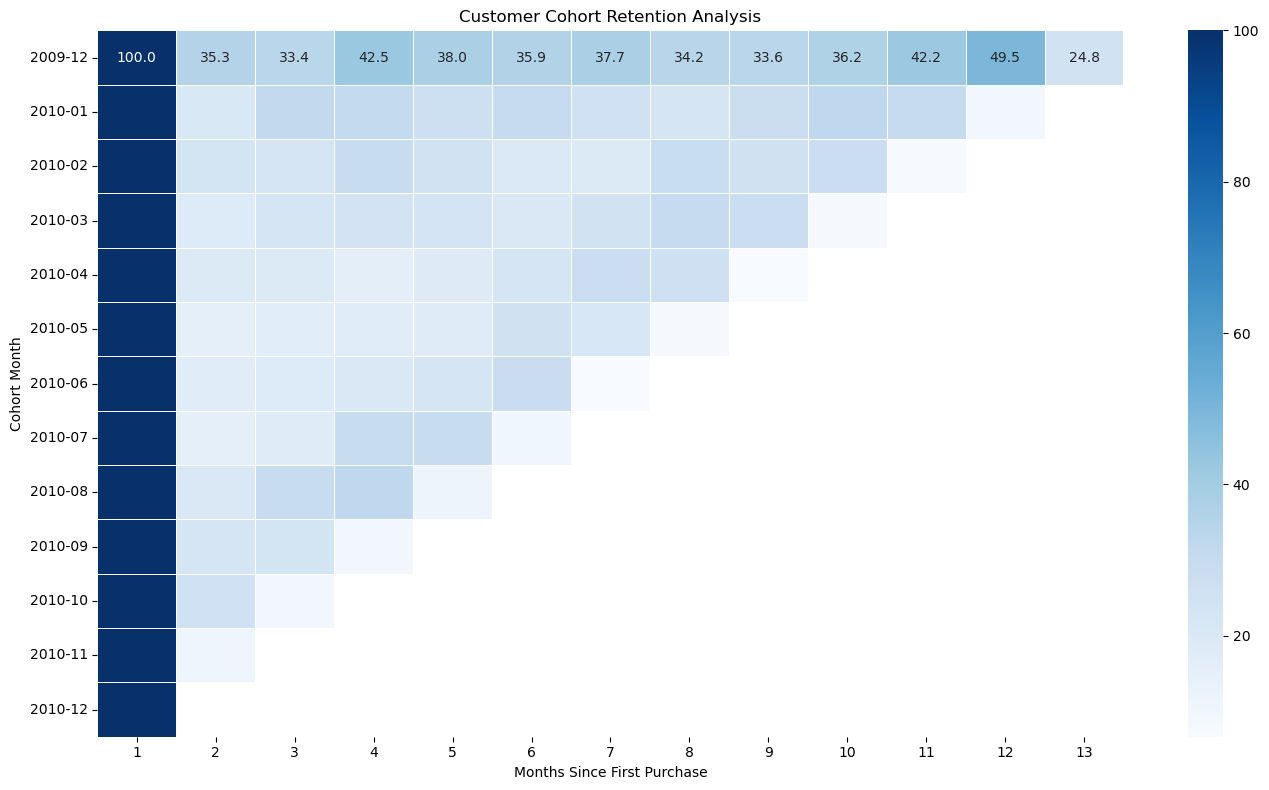

In [43]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_table,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Customer Cohort Retention Analysis')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')

plt.tight_layout()

plt.savefig(
    'cohort_retention_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 21. Calculate Average Retention by Cohort Period

The average retention rate is calculated across all available cohorts
for each month since the first purchase.

This helps identify how customer retention changes over time.

In [44]:
average_retention = retention_table.mean(axis=0)

average_retention.round(2)

CohortIndex
1     100.00
2      20.53
3      22.35
4      25.19
5      23.56
6      24.14
7      23.27
8      25.02
9      24.26
10     25.88
11     26.57
12     29.72
13     24.82
dtype: float64

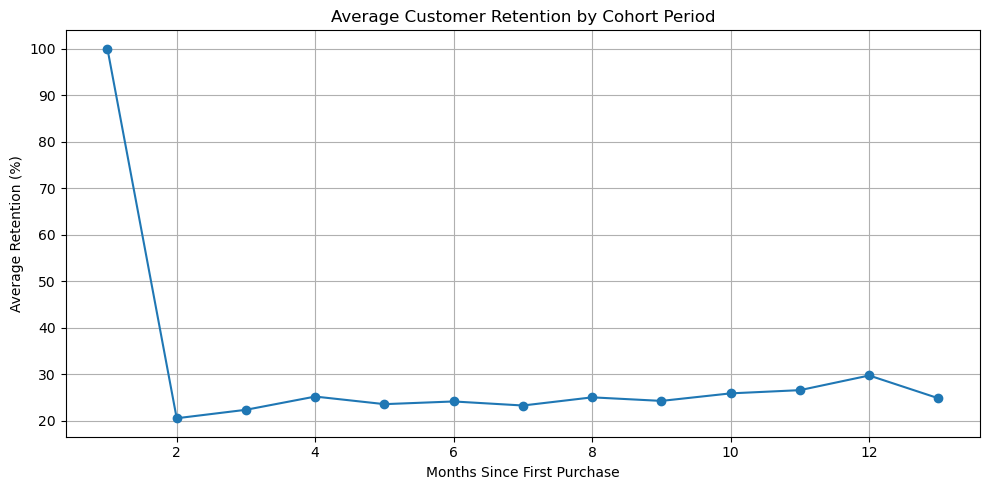

In [45]:
plt.figure(figsize=(10, 5))

plt.plot(
    average_retention.index,
    average_retention.values,
    marker='o'
)

plt.title('Average Customer Retention by Cohort Period')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Average Retention (%)')
plt.grid(True)

plt.tight_layout()
plt.show()

## 22. Calculate One-Month Customer Retention

One-month retention measures the average percentage of customers
who made another purchase one month after their first purchase.

This is an important metric for understanding early customer retention.

In [46]:
month_1_retention = retention_table[2].mean()

print(
    f"Average One-Month Retention: {month_1_retention:.2f}%"
)

Average One-Month Retention: 20.53%


## 23. Calculate Three-Month Customer Retention

Three-month retention measures the average percentage of customers
who remain active three months after their first purchase.

Comparing one-month and three-month retention helps understand
customer retention beyond the initial repeat-purchase period.

In [47]:
month_3_retention = retention_table[4].mean()

print(
    f"Average Three-Month Retention: {month_3_retention:.2f}%"
)

Average Three-Month Retention: 25.19%


## 24. Key Retention Insights

The cohort analysis provides the following observations:

1. The initial cohort period has 100% retention because it represents
   the original customer population.

2. Average one-month retention is 20.53%, indicating that approximately
   one-fifth of customers returned one month after their first purchase,
   based on the available cohorts.

3. Average three-month retention is 25.19%. This should be interpreted
   carefully because fewer cohorts have three-month observations.

4. The heatmap shows different retention patterns across customer
   cohorts, indicating that customer behavior varies by acquisition period.

5. Later cohort periods contain fewer observations because newer cohorts
   have had less time to generate subsequent purchases.

## 25. Business Recommendations and Conclusion

### Business Recommendations

- Monitor early customer retention after the first purchase.
- Identify cohorts with relatively stronger or weaker retention patterns.
- Develop targeted customer engagement strategies for customers who do
  not make a repeat purchase.
- Compare retention across acquisition periods to understand changes in
  customer behavior.
- Continue monitoring newer cohorts as more customer history becomes available.

### Conclusion

Cohort retention analysis provides a structured way to understand
customer behavior over time. In this project, customers were grouped
according to their first purchase month, and their subsequent activity
was measured using unique customer counts.

The analysis produced a cohort retention table and heatmap that show
how customer retention changes across different cohorts and periods.
The calculated metrics can support data-driven customer retention and
engagement analysis.

## 26. Export Cohort Retention Table

The final cohort retention table is exported as a CSV file.
This file can be used for reporting, documentation, and portfolio presentation.

In [48]:
retention_table.to_csv(
    'cohort_retention_table.csv'
)

In [49]:
import os

os.path.exists('cohort_retention_table.csv')

True

## 27. Final Cohort Retention Table

The final retention table summarizes the percentage of customers
retained across different months since their first purchase.

In [50]:
retention_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,42.20,49.53,24.82
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,30.29,9.92,NaN
2010-02,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,7.22,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,6.80,NaN,NaN,NaN,NaN
2010-05,100.0,15.75,16.93,17.32,17.72,25.59,21.26,7.87,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.41,18.89,20.37,22.96,28.52,6.67,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.59,18.28,29.57,29.03,10.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.37,29.63,32.10,11.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 28. Project Summary

### Project Title
Customer Cohort Retention Analysis

### Objective
The objective of this project is to analyze customer retention
over time by grouping customers according to their first purchase month.

### Dataset
Online Retail II dataset

### Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Analysis Performed
- Data cleaning and preprocessing
- Removed missing Customer IDs
- Removed cancelled transactions
- Removed invalid quantities and prices
- Created monthly transaction periods
- Identified customer cohort months
- Calculated cohort indexes
- Counted unique customers
- Calculated retention percentages
- Created a cohort retention table
- Created a retention heatmap
- Calculated retention metrics
- Generated business insights

## 29. Business Insights

### Key Findings

1. The first purchase period has 100% retention because it represents
   the original customer cohort.

2. The average one-month customer retention is 20.53%.

3. The average three-month customer retention is 25.19%.

4. The retention heatmap shows different retention patterns across
   customer cohorts.

5. The 2009-12 cohort contains the longest observation period in the
   analysis, allowing retention to be observed across 13 cohort periods.

6. Newer cohorts contain more NaN values in later periods because there
   is not enough subsequent transaction history available for those cohorts.

7. Cohort analysis provides a better view of customer behavior over time
   than a single overall retention metric.